## HW3
#### GUO TIANYUE

Refer to some ways of language grammar in ChatGpt.

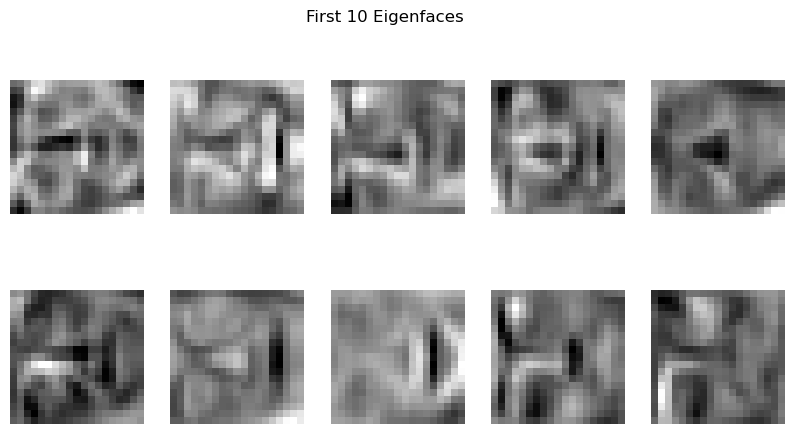

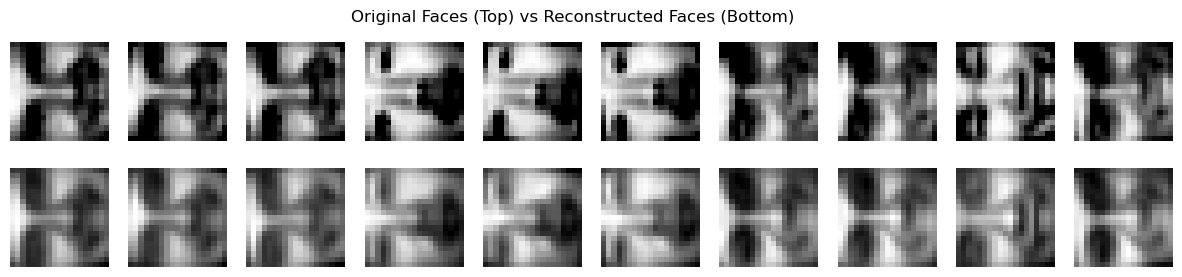

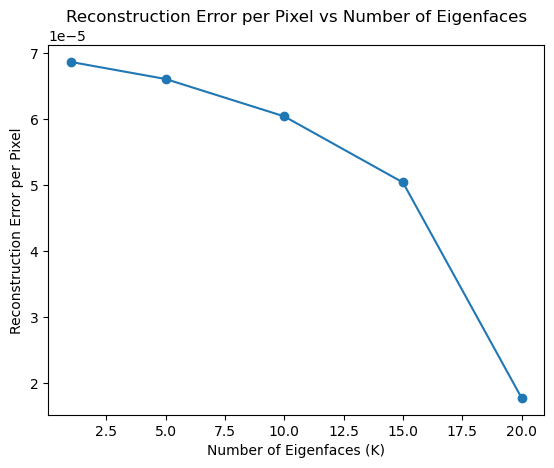

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load and split the data
X = np.loadtxt("face.txt", delimiter=' ')
train_data = X[:2100]
test_data = X[2100:]

# Step 1: Calculate the mean face and subtract it from the training set
mean_face = np.mean(train_data, axis=0)
centered_train_data = train_data - mean_face

# Step 2: Calculate the covariance matrix and eigen decomposition
cov_matrix = np.dot(centered_train_data, centered_train_data.T) / train_data.shape[0]
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Transform eigenvectors to match the dimensions of the original data
eigenfaces = np.dot(centered_train_data.T, eigenvectors).T
eigenfaces = eigenfaces[-20:]  # Take the top 20 eigenfaces (corresponding to largest eigenvalues)
eigenfaces /= np.linalg.norm(eigenfaces, axis=1).reshape(-1, 1)  # Normalize

# Step 3: Display the first 10 eigenfaces
fig, axs = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(eigenfaces[i].reshape(19, 19), cmap='gray')
    ax.axis('off')
plt.suptitle("First 10 Eigenfaces")
plt.show()

# Step 4: Reconstruct test faces and calculate reconstruction error
K_values = [1, 5, 10, 15, 20]
reconstruction_errors = []

for K in K_values:
    top_k_eigenfaces = eigenfaces[:K]
    projections = np.dot(test_data - mean_face, top_k_eigenfaces.T)
    reconstructed_faces = np.dot(projections, top_k_eigenfaces) + mean_face
    error = np.mean((reconstructed_faces - test_data) ** 2) / test_data.shape[1]
    reconstruction_errors.append(error)

# Step 5: Display 10 reconstructed test faces and original faces
fig, axs = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axs[0, i].imshow(test_data[i].reshape(19, 19), cmap='gray')
    axs[0, i].axis('off')
    axs[1, i].imshow(reconstructed_faces[i].reshape(19, 19), cmap='gray')
    axs[1, i].axis('off')
plt.suptitle("Original Faces (Top) vs Reconstructed Faces (Bottom)")
plt.show()

# Step 6: Plot reconstruction error per pixel for different values of K
plt.plot(K_values, reconstruction_errors, marker='o')
plt.xlabel('Number of Eigenfaces (K)')
plt.ylabel('Reconstruction Error per Pixel')
plt.title('Reconstruction Error per Pixel vs Number of Eigenfaces')
plt.show()

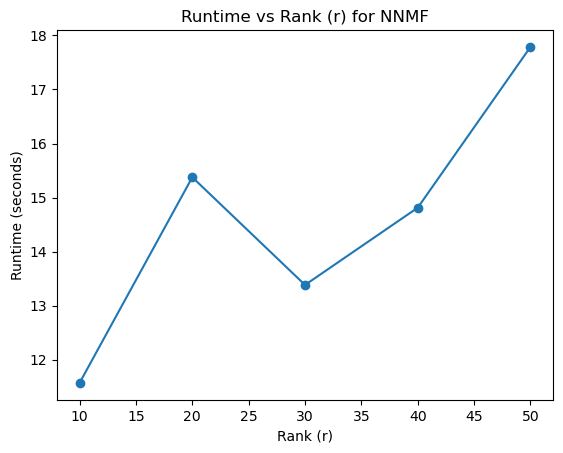

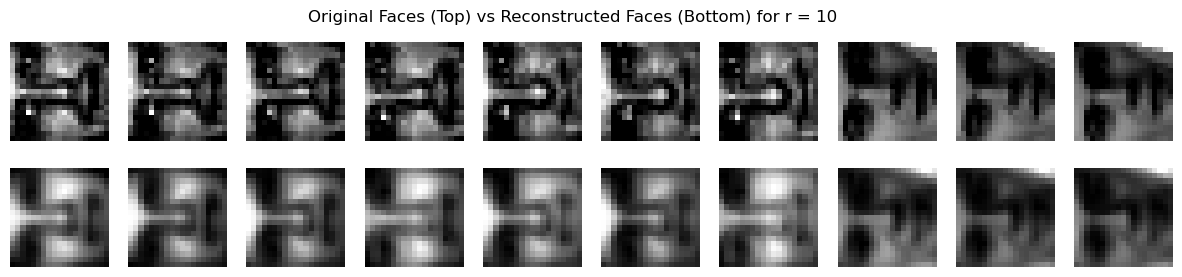

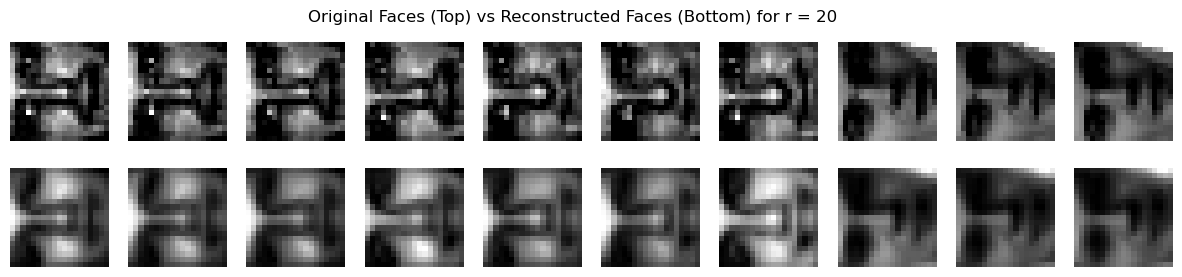

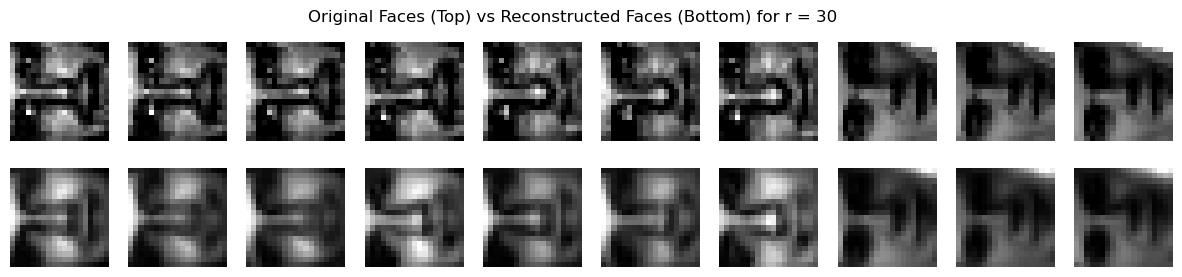

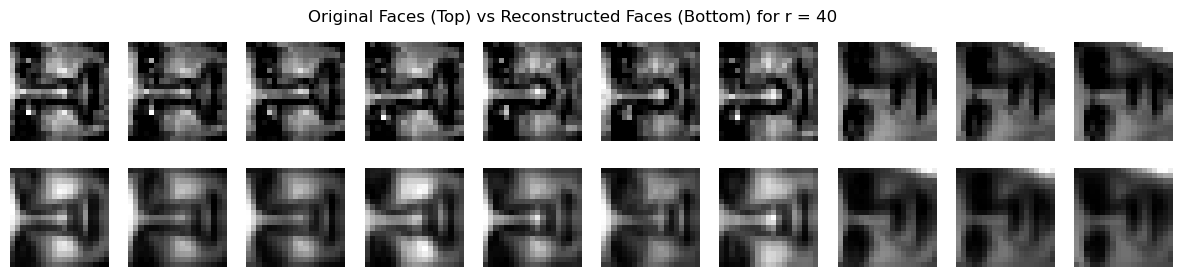

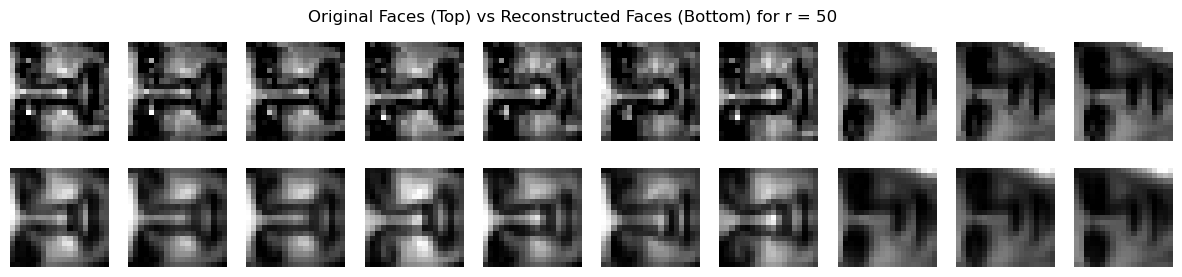

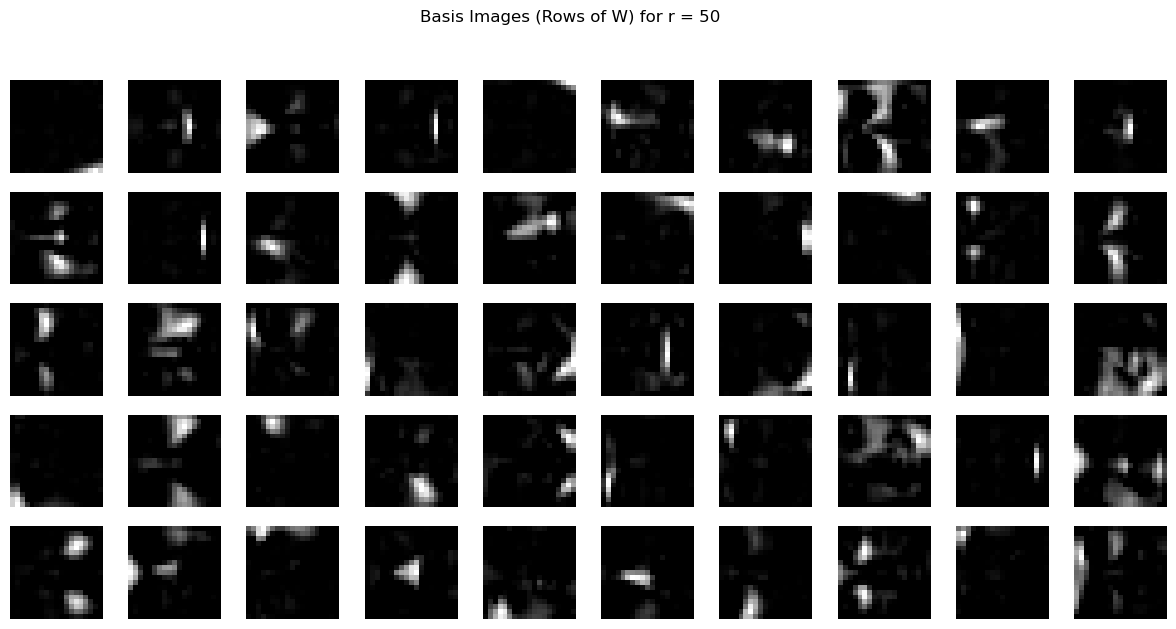

Do we get the same result with different initializations? No


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

def nnmf(X, r, maxiter=1000, tol=1e-4, V=None, W=None):
    if V is None:
        V = np.random.rand(X.shape[0], r)
    if W is None:
        W = np.random.rand(r, X.shape[1])

    for t in range(maxiter):
        # Update V
        V_num = np.dot(X, W.T)
        V_denom = np.dot(np.dot(V, W), W.T)
        V = V * (V_num / (V_denom + 1e-10))  # Avoid division by zero

        # Update W
        W_num = np.dot(V.T, X)
        W_denom = np.dot(V.T, np.dot(V, W))
        W = W * (W_num / (W_denom + 1e-10))  # Avoid division by zero

        # Calculate the approximation error (Frobenius norm)
        error = np.linalg.norm(X - np.dot(V, W), 'fro')
        if error < tol:
            break

    return V, W

# Part i) Runtime vs r
r_values = [10, 20, 30, 40, 50]
runtimes = []
for r in r_values:
    start_time = time.time()
    V, W = nnmf(X, r)
    runtimes.append(time.time() - start_time)

plt.plot(r_values, runtimes, marker='o')
plt.xlabel('Rank (r)')
plt.ylabel('Runtime (seconds)')
plt.title('Runtime vs Rank (r) for NNMF')
plt.show()

# Part ii) Reconstructed faces for each r and comparison with original
for r in r_values:
    V, W = nnmf(X, r)
    reconstructed_faces = np.dot(V, W)
    fig, axs = plt.subplots(2, 10, figsize=(15, 3))
    for i in range(10):
        axs[0, i].imshow(X[i].reshape(19, 19), cmap='gray')  # Original face
        axs[0, i].axis('off')
        axs[1, i].imshow(reconstructed_faces[i].reshape(19, 19), cmap='gray')  # Reconstructed face
        axs[1, i].axis('off')
    plt.suptitle(f"Original Faces (Top) vs Reconstructed Faces (Bottom) for r = {r}")
    plt.show()

# Part iii) Basis images for r = 50
r = 50
V, W = nnmf(X, r)
fig, axs = plt.subplots(5, 10, figsize=(15, 7))
for i in range(50):
    axs[i // 10, i % 10].imshow(W[i].reshape(19, 19), cmap='gray')
    axs[i // 10, i % 10].axis('off')
plt.suptitle("Basis Images (Rows of W) for r = 50")
plt.show()

# Part iv) Different initializations for r = 30
r = 30
V1, W1 = nnmf(X, r)
V2, W2 = nnmf(X, r, V=np.random.rand(X.shape[0], r), W=np.random.rand(r, X.shape[1]))

# Check if the results are the same
same_results = np.allclose(np.dot(V1, W1), np.dot(V2, W2))
print(f"Do we get the same result with different initializations? {'Yes' if same_results else 'No'}")


The output is not guaranteed to be the same because NNMF can converge to different local minima depending on the initialization. This result reflects the non-convex nature of NNMF.

To verify that using \( N(x) \) to build a spline regression model will result in a natural spline, we need to show that for \( X < X_1 \) and \( X > X_p \), \( y \) becomes a linear function with only intercept and slope terms. This means that at the boundaries (outside the smallest and largest knots), the spline function should behave linearly.

### Steps to Verify

1. **Define the Spline Model**:  
   From the slide, the spline regression model is given by:
   \[
   y = \beta_0 + \beta_1 x + \sum_{j=1}^p \beta_{j+1} N_j(x)
   \]
   where \( N_j(x) \) are the basis functions designed to enforce natural spline constraints.

2. **Basis Functions for Natural Splines**:  
   For a natural spline, we impose additional constraints on \( N_j(x) \) at the boundaries:
   - When \( X < X_1 \): The spline function is constrained to be close to linear, i.e., it has no additional curvature.
   - When \( X > X_p \): Similarly, the spline function is constrained to be linear.

3. **Behavior at Boundaries**:  
   To achieve linearity at \( X < X_1 \) and \( X > X_p \), the basis functions \( N_j(x) \) are designed such that they become zero outside the range of the knots. Specifically:
   - \( N_j(x) = 0 \) when \( X < X_1 \) for all \( j > 1 \).
   - \( N_j(x) = 0 \) when \( X > X_p \) for all \( j > 1 \).

   This means that outside the range \( [X_1, X_p] \), the sum \( \sum_{j=1}^p \beta_{j+1} N_j(x) \) vanishes, leaving only the terms \( \beta_0 + \beta_1 x \), which represent a linear function in \( x \).

4. **Conclusion**:  
   Therefore, at \( X < X_1 \) and \( X > X_p \), the model simplifies to:
   \[
   y = \beta_0 + \beta_1 x
   \]
   This shows that \( y \) is just a linear function with only the intercept (\( \beta_0 \)) and slope (\( \beta_1 \)) terms when \( X \) is outside the range of the knots, which confirms that using \( N(x) \) as specified creates a natural spline.

This verifies the conclusion that the model will indeed be a natural spline as it satisfies the boundary conditions necessary for a natural spline (linear behavior outside the knot range).
